# Difference in Differences

files needed = ('public.dat', 'sw06.csv')

Today, we'll consider one of the most common models for estimating causal effects, the difference-in-differences model. We'll start with the canonical design, with two groups and two periods. After we build some more time-series tools, we'll move to more complicated specifications.

Difference-in-differences, or diff-in-diffs, or DiD, is an oldie but a goodie. The first known application was in the 1840s! Nevertheless, according to [Currie, Kleven, and Zwiers (2020)](https://www.aeaweb.org/articles?id=10.1257/pandp.20201058), almost 25% of empirical working papers circulated by the National Bureau of Economic Research (NBER) mentioned DiD as recently as 2018.

DiD is essentially an econometric specification for estimating the effects of a quasi-experiment. As in an RCT, there are treated and control groups. However, there is often no contention that treatment is *random*. Treatment is often driven by policy, regulation, firm strategy, consumer choice, etc. The identification strategy is to find a control group for the treated units such that any factors that *do* differ between the treated and control units are *time-invariant*. If such a control group exists, the trends in outcomes for control units are a plausible *counterfactual* for what would have happened to treated units ***in the absence of treatment***.

## Example

Let's start with by replicating Card and Krueger (1994), "Minimum wages and employment," one of the most famous difference-in-differences regressions in the literature. 

The [data](https://davidcard.berkeley.edu/data_sets.html) and [paper](https://davidcard.berkeley.edu/papers/njmin-aer.pdf) are available at Card's website.

There are several people on the web who have attempted this replication. I found [Aaron Mamula's](https://aaronmams.github.io/Card-Krueger-Replication/) work useful. 

### Background

How does the minimum wage affect employment? Theory predicts that a binding minimum wage should decrease employment in occupations or worker types whose equilibrium wage would be less than the minimum wage. This paper looks at a change in the minimum wage in New Jersey from \\$4.25 to \\$5.05 in 1992. Pennsylvania, a neighboring state, did not change its minimum wage. So the first difference is 'before vs. after 1992' and second difference is 'PA vs. NJ'. 

Card and Krueger collected data from fast-food restaurants before and after the policy change. Fast food is a good industry to study because such restaurants tend to pay low wages and are therefore likely to be affected by the change in policy. 

In [8]:
import pandas as pd
import numpy as np
from pandas import option_context
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf 
import os
os.chdir('/Users/jackson/Documents/ECON570')

### Loading the data

Card and Krueger were using SAS. Getting the data into a DataFrame takes a bit of hassle. One can dig out the variable names from the codebook and create the list below. 

For practice, you could try reading in the codebook and use `readline()` and the like to extract the variable names and create the list. 

In [9]:
c = ['SHEET', 'CHAIN', 'CO_OWNED', 'STATE', 'SOUTHJ','CENTRALJ','NORTHJ','PA1','PA2','SHORE','NCALLS','EMPFT','EMPPT',
'NMGRS' ,'WAGE_ST','INCTIME','FIRSTINC','BONUS','PCTAFF','MEALS','OPEN','HRSOPEN','PSODA','PFRY','PENTREE','NREGS',
'NREGS11','TYPE2','STATUS2','DATE2','NCALLS2','EMPFT2','EMPPT2','NMGRS2','WAGE_ST2','INCTIME2','FIRSTIN2','SPECIAL2',
'MEALS2','OPEN2R','HRSOPEN2','PSODA2','PFRY2','PENTREE2','NREGS2','NREGS112']

The data file is in fixed-width format. I'm using `pd.read_fwf()` to read in the file. Pandas will guess at the layout (how many columns define a variable), and it got it right this time. If pandas cannot figure it out, you can pass it a column spec. ([docs](https://pandas.pydata.org/docs/reference/api/pandas.read_fwf.html))

I'm only keeping the columns I need. Then, I'm recoding the state variable so I don't have to remember that `NJ = 1`.

In [10]:
ck = pd.read_fwf('data/public.dat', header=None, na_values='.', names=c)
ck = ck[['SHEET', 'STATE', 'EMPFT', 'EMPPT', 'EMPFT2', 'EMPPT2', 'NMGRS', 'NMGRS2', 
         'STATUS2', 'WAGE_ST', 'WAGE_ST2', 'CO_OWNED', 'CHAIN', 
         'SOUTHJ', 'CENTRALJ', 'NORTHJ', 'PA1', 'PA2', 'SHORE']]
ck['STATE'] = ck['STATE'].replace({1:'NJ', 0:'PA'})

ck.head(3)

,SHEET,STATE,EMPFT,EMPPT,EMPFT2,EMPPT2,NMGRS,NMGRS2,STATUS2,WAGE_ST,WAGE_ST2,CO_OWNED,CHAIN,SOUTHJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE
0,46,PA,30.0,15.0,3.5,35.0,3.0,3.0,1,NaN,4.30,0,1,0,0,0,1,0,0
1,49,PA,6.5,6.5,0.0,15.0,4.0,4.0,1,NaN,4.45,0,2,0,0,0,1,0,0
2,506,PA,3.0,7.0,3.0,7.0,2.0,4.0,1,NaN,5.00,1,2,0,0,0,1,0,0


### Create the full time equivalent variable

The total employment variable is full-time employees, plus managers, plus one-half the part-time employees. 

In [11]:
ck['FTE_before'] =   ck['EMPFT'] +  ck['NMGRS'] + 0.5*ck['EMPPT']
ck['FTE_after'] = ck['EMPFT2'] + ck['NMGRS2'] + 0.5*ck['EMPPT2']

### CK's Table 3 

Here is the northwest corner of table 3. 

|          | PA | NJ | NJ-PA|
-----------|----|----|------|
|FTE before| 23.33|20.44 | -2.89| 
|          |(1.35)|(0.51)|(1.44)|
|FTE after| 21.17|21.03 | -0.14| 
|          |(0.94)|(0.52)|(1.07)|

In [12]:
t3 = ck[['STATE', 'FTE_before', 'FTE_after']].groupby('STATE').agg(['mean', 'sem']).transpose()

t3 = t3[['PA', 'NJ']]
t3['NJ-PA'] = t3['NJ'] - t3['PA']

# Fix the standard error of the mean differences
t3.loc[('FTE_before', 'sem'), 'NJ-PA'] = (t3.loc[('FTE_before', 'sem'), 'PA']**2 + t3.loc[('FTE_before', 'sem'), 'NJ']**2)**(0.5)
t3.loc[('FTE_after', 'sem'),  'NJ-PA'] = (t3.loc[('FTE_after', 'sem'),  'PA']**2 + t3.loc[('FTE_after',  'sem'), 'NJ']**2)**(0.5)

with option_context('display.precision', 2):
    display(t3)

STATE               PA     NJ  NJ-PA
FTE_before mean  23.33  20.41  -2.92
           sem    1.35   0.51   1.44
FTE_after  mean  21.17  21.03  -0.14
           sem    0.94   0.52   1.08

The difference between the PA and NJ stores actually shrinks after NJ raises its minimum wage. NJ stores are, on average, hiring more people and PA stores are hiring fewer people. 

Let's calculate the difference-in-differences of the means:

$$ DID = ( \overline{y}_{NJ,post} - \overline{y}_{PA,post} ) - ( \overline{y}_{NJ,pre} - \overline{y}_{PA,pre} ) $$

In [13]:
did = t3.loc[('FTE_after','mean'),'NJ-PA']-t3.loc[('FTE_before','mean'),'NJ-PA']
print("Difference in Differences: {:.2f}".format(did))

Difference in Differences: 2.78


### Parallel trends assumption

What do we need to interpret this simple difference-in-differences as a causal effect? One common assumption is the parallel trends assumption. In this case, we assume that NJ's change in FTE would have seen the same change in `fte` as PA if there had been no change in the minimum wage.

Let's plot the average employment before and after the policy change in each state, and also the counterfactual level of employment in New Jersey if they **had not** increased the minimum wage, under the parallel trend assumption.

In [14]:
# Keep only the means from t3 
pta = t3.drop(columns='NJ-PA')
pta = pta.xs('mean',level=1)
# construct the counterfactual fte path for NJ without the treatment
pta['NJcount'] = pta['NJ']
pta.loc['FTE_after', 'NJcount'] = pta.loc['FTE_before', 'NJ']+(pta.loc['FTE_after', 'PA']-pta.loc['FTE_before', 'PA'])

with option_context('display.precision', 2):
    display(pta)

STATE,PA,NJ,NJcount
FTE_before,23.33,20.41,20.41
FTE_after,21.17,21.03,18.24


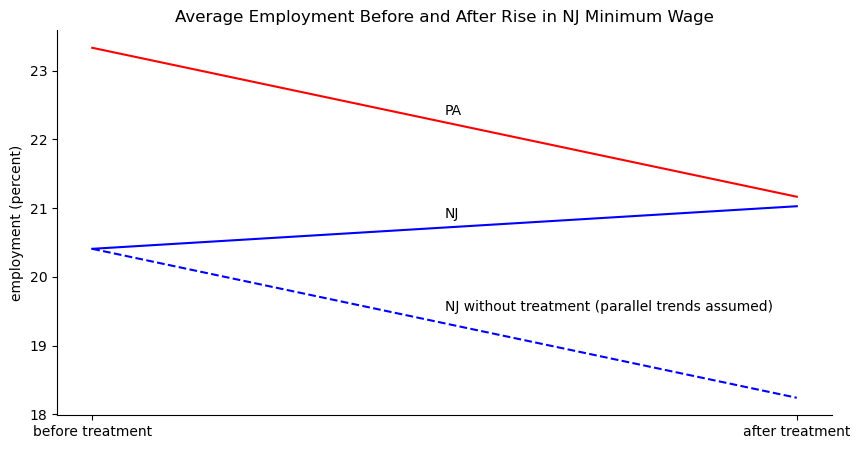

In [15]:
fig, ax = plt.subplots(figsize=(10,5)) 
ax.plot(pta.index, pta['PA'], label='PA', color='red')  
ax.plot(pta.index, pta['NJ'], label='NJ', color='blue')  
ax.plot(pta.index, pta['NJcount'], label='NJcount', color='blue',linestyle='--')  

plt.xticks(ticks=[0,1], labels=['before treatment','after treatment'])
ax.text(.5, 22.35, 'PA')
ax.text(.5, 20.85, 'NJ')
ax.text(.5, 19.5, 'NJ without treatment (parallel trends assumed)')

ax.set_title('Average Employment Before and After Rise in NJ Minimum Wage')
ax.set_ylabel('employment (percent)')
sns.despine(ax=ax)

plt.show()

The vertical distance between the solid blue and dashed line after treatment is 2.78: this is the difference-in-differences! The parallel trends assumption gives this estimate a *causal interpretation*.

Interesting first cut of the data. The next step is to control for some other variables and see if the result holds up. 

### CK's Table 4, model 1

Here goes the first regression. 

$$\Delta E_i = a + b \text{NJ}_i+\epsilon_i$$

where $\Delta E_i$ is the change in employment before and after the minimum wage change and NJ is equal to 1 if the store is in New Jersey and 0 otherwise. 

In [16]:
# I'm trying to follow the sample selection given in the notes of table 4. I have 6 too few stores. Not sure why.
rd = ck[(ck['FTE_after'].isna()==False) & (ck['FTE_before'].isna()==False) & (ck['WAGE_ST'].isna()==False) & (ck['WAGE_ST2'].isna()==False) ].copy()

rd['Emp_diff'] = rd['FTE_after'] - rd['FTE_before']

In [17]:
res1 = smf.ols("Emp_diff ~ C(STATE, Treatment(reference='PA'))", data=rd).fit(cov_type='HC3')
print(res1.summary())

                            OLS Regression Results                            
Dep. Variable:               Emp_diff   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     2.485
Date:                Tue, 28 Oct 2025   Prob (F-statistic):              0.116
Time:                        13:12:38   Log-Likelihood:                -1256.9
No. Observations:                 351   AIC:                             2518.
Df Residuals:                     349   BIC:                             2526.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

Increasing the minimum wage did not cause employment to fall. That result earned this paper 5k Google Scholar citations. 

My results are close, but not identical to those in the published paper. I don't have the sample selection correct. I suspect I could run the SAS code and figure it out...

## Practice
It's common to present multiple specifications of a DiD regression, in order to test robustness to different samples and sets of controls and to explore the shape of the treatment effect. Let's try to replicate more of the results.

1. Try some of the other regressions in table 4. For models (iii)&ndash;(v) you will need to create the gap measure. It is defined on page 779. You likely won't get the coefficient exactly right&mdash;I haven't been able to match the sample correctly. But your numbers should be in the ball park. 
2. Once you have estimated a couple models, try putting the results into a table similar to table 4. 

* `CHAIN` is the control for chain stores, it takes values 1, 2, 3, or 4.
* `CO_OWNED` is the control for company ownership (rather than franchise). It takes 0 or 1 as values.
* `WAGE_ST` is the wage in the "before" period.
* `SOUTHJ`, `CENTRALJ`, `NORTHJ`, `PA1`, `PA2`, `SHORE` are the controls for regions. Each takes 0 or 1 as values.